## **Análise Exploratória de Dados - Projeto Alpargatas**
___

**Objetivo:** Este notebook tem como finalidade carregar o DataFrame consolidado, que une dados de diversas fontes públicas e privadas, para realizar uma análise exploratória. O foco é segmentar os municípios com base em características demográficas e socioeconômicas para entender o perfil de atuação do Instituto Alpargatas e identificar fatores correlacionados com o desempenho educacional, medido pelo IDEB.

Esta análise é um passo fundamental para o desenvolvimento de uma ferramenta de apoio à decisão que visa combater a evasão escolar de forma mais estratégica.

**1. Configuração Inicial e Importações**

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Define o caminho para os dados processados (ajuste se necessário)
PROJETO_DIR = Path().resolve().parent
PROCESSED_DATA_DIR = PROJETO_DIR / 'data' / 'processed'

**2. Carregamento dos Dados Consolidados**

In [4]:
try:
    data_final = pd.read_parquet(
        PROCESSED_DATA_DIR / 'data_final_consolidado.parquet')
    print('DataFrame final consolidado carregado com sucesso!')
    print(
        f"O DataFrame possui {data_final.shape[0]} linhas e {data_final.shape[1]} colunas.")
except FileNotFoundError:
    print('ERRO: O arquivo "data_final_consolidado.parquet" não foi encontrado')
    print('Tente executar o script "data_processing.py" primeiro.')

DataFrame final consolidado carregado com sucesso!
O DataFrame possui 11140 linhas e 16 colunas.


**3. Segmentação e Análise de Perfil dos Municípios**

Nesta etapa, novas colunas (features) são criadas para categorizar e agrupar os municípios, permitindo análises comparativas mais ricas.

**3.1. Identificação de Municípios com e sem Projetos**

A coluna tem_projeto_ia foi criada para facilmente identificar e filtrar os municípios onde o Instituto atua. O data_final foi criado com um merge à esquerda, então municípios que não estavam na base de projetos (proj_IA) recebem um valor nulo (NaN) na coluna nr_projetos. Usamos essa lógica para criar a flag.

In [5]:
# A função np.where verifica a condição e atribui 'Sim' ou 'Não' conforme o resultado.
data_final['tem_projeto_ia'] = np.where(
    data_final['nr_projetos'].notna(), 'Sim', 'Não')

# Vamos verificar a distribuição de municípios com e sem projetos por ano.
distribuicao_projetos = data_final.groupby(
    'ano')['tem_projeto_ia'].value_counts().unstack()
print('Distribuição de municípios com e sem projetos IA (por ano):')
print(distribuicao_projetos)

Distribuição de municípios com e sem projetos IA (por ano):
tem_projeto_ia   Não  Sim
ano                      
2020            5557   13
2021            5555   15


**3.2. Segmentação por Categoria de Riqueza (PIB per Capita)**

Para permitir uma comparação justa entre os municípios, segmentamo-os por nível de riqueza. Usamos a função pd.qcut para dividir os municípios em 4 grupos de tamanho igual (quartis) com base no seu PIB per capita.

In [6]:
try:
    data_final['categoria_pib'] = pd.qcut(
        data_final['pib_per_capita'],
        q=4,  # Define o número de quantis (4 = quartis)
        labels=['Baixo', 'Médio-Baixo', 'Médio-Alto', 'Alto']
    )

    print('\n:.: Segmentação de Municípios por Categoria de PIB :.:')
    print(data_final['categoria_pib'].value_counts())
except Exception as e:
    print(f'\nNão foi possível criar a categoria de PIB. Erro: {e}')


:.: Segmentação de Municípios por Categoria de PIB :.:
categoria_pib
Baixo          2785
Médio-Baixo    2785
Médio-Alto     2785
Alto           2785
Name: count, dtype: int64


**3.3. Segmentação por Porte Populacional**

Além da riqueza, o tamanho do município é um fator importante. São cirados grupos ('Pequeno', 'Médio', 'Grande') baseados em faixas de população pré-definidas usando a função np.select.

In [7]:
try:
    condicoes_porte = [
        (data_final['populacao'] <= 20000),
        (data_final['populacao'] > 20000) & (
            data_final['populacao'] <= 100000),
        (data_final['populacao'] > 100000)
    ]
    opcoes_porte = ['Pequeno', 'Médio', 'Grande']
    data_final['porte_municipio'] = np.select(
        condicoes_porte, opcoes_porte, default='Não definido')

    print('\n:.: Segmentação de Municípios por Porte :.:')
    print(data_final['porte_municipio'].value_counts())
except Exception as e:
    print(f'\nNão foi possível criar a categoria de porte. Erro: {e}')


:.: Segmentação de Municípios por Porte :.:
porte_municipio
Pequeno    7553
Médio      2935
Grande      652
Name: count, dtype: int64


**4. Análise Comparativa e Descoberta de Insights**

Com os dados devidamente segmentados, podemos agora cruzar as informações para testar a hipótese principal do projeto.

**4.1. Análise Principal: IDEB Médio por Riqueza e Presença de Projeto**

Esta é a análise central, que busca validar a hipótese de que o Instituto atua de forma estratégica em municípios com maiores desafios educacionais. Agrupamos os dados para calcular a média do IDEB para cada combinação de categoria de PIB e presença de projeto.

In [13]:
analise_pib_ideb = data_final.groupby(['categoria_pib', 'tem_projeto_ia'])[
    'ideb_nota'].mean().unstack().round(2)

print(' ANÁLISE: IDEB MÉDIO POR CATEGORIA DE PIB E PRESENÇA DE PROJETO IA '.center(80, '='))
print(analise_pib_ideb.reset_index())

====== ANÁLISE: IDEB MÉDIO POR CATEGORIA DE PIB E PRESENÇA DE PROJETO IA =======
tem_projeto_ia categoria_pib   Não   Sim
0                      Baixo  5.04  4.60
1                Médio-Baixo  5.35  4.93
2                 Médio-Alto  5.81  5.40
3                       Alto  5.95  5.65


C:\Users\letic\AppData\Local\Temp\ipykernel_9388\2542585307.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise_pib_ideb = data_final.groupby(['categoria_pib', 'tem_projeto_ia'])[


**4.2. Análise de Foco: Distribuição de Projetos por Porte do Município**

In [10]:
analise_porte_projetos = data_final.groupby(
    'porte_municipio')['nr_projetos'].sum().reset_index()

print(' ANÁLISE: Nº DE PROJETOS POR PORTE DE MUNICÍPIO '.center(80, '='))
print(analise_porte_projetos)

================ ANÁLISE: Nº DE PROJETOS POR PORTE DE MUNICÍPIO ================
  porte_municipio  nr_projetos
0          Grande          6.0
1           Médio         11.0
2         Pequeno          7.0


**4.3. Análise Detalhada: Cruzamento de Porte, Riqueza e IDEB**

In [11]:
analise_detalhada = data_final.groupby(['porte_municipio',
                                        'categoria_pib',
                                        'tem_projeto_ia'])['ideb_nota'].mean().unstack().round(2)

print(' ANÁLISE DETALHADA: IDEB POR PORTE, PIB E PROJETO '.center(80, '='))
print(analise_detalhada.reset_index())

=============== ANÁLISE DETALHADA: IDEB POR PORTE, PIB E PROJETO ===============
tem_projeto_ia porte_municipio categoria_pib   Não   Sim
0                       Grande         Baixo  4.75   NaN
1                       Grande   Médio-Baixo  5.15  4.00
2                       Grande    Médio-Alto  5.57  5.70
3                       Grande          Alto  5.97  5.65
4                        Médio         Baixo  4.93  4.90
5                        Médio   Médio-Baixo  5.21  5.25
6                        Médio    Médio-Alto  5.75  4.80
7                        Médio          Alto  5.91   NaN
8                      Pequeno         Baixo  5.09  4.45
9                      Pequeno   Médio-Baixo  5.43  4.60
10                     Pequeno    Médio-Alto  5.87   NaN
11                     Pequeno          Alto  5.97   NaN


C:\Users\letic\AppData\Local\Temp\ipykernel_9388\251231584.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise_detalhada = data_final.groupby(['porte_municipio',


**5. Visualização dos Resultados**

Conforme o plano do projeto, a criação de uma ferramenta de visualização é um objetivo chave. Abaixo está o código para gerar o gráfico de barras que ilustra nossa principal descoberta.

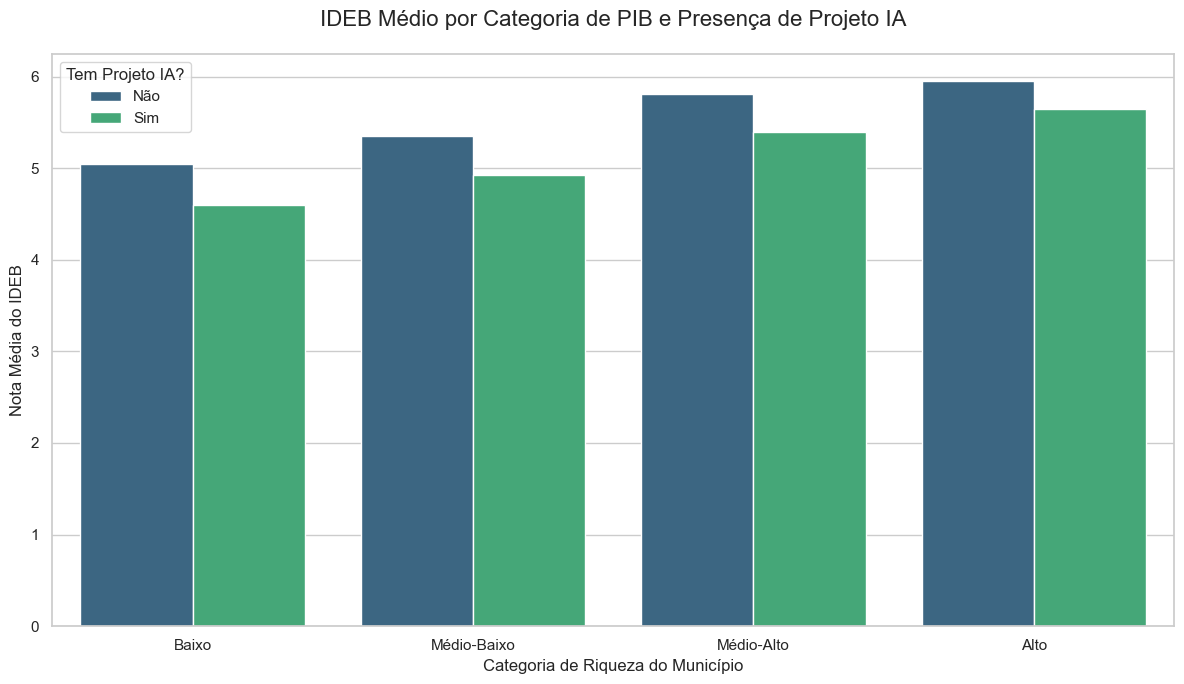

In [12]:
# Prepara os dados para o formato ideal para o Seaborn (formato 'longo')
df_para_plot = analise_pib_ideb.reset_index().melt(
    id_vars='categoria_pib', var_name='tem_projeto_ia', value_name='ideb_nota')

# Cria a figura e os eixos para o gráfico
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Desenha o gráfico de barras
ax = sns.barplot(data=df_para_plot, x='categoria_pib',
                 y='ideb_nota', hue='tem_projeto_ia', palette='viridis')

# Adiciona títulos e rótulos para clareza
ax.set_title(
    'IDEB Médio por Categoria de PIB e Presença de Projeto IA', fontsize=16, pad=20)
ax.set_xlabel('Categoria de Riqueza do Município', fontsize=12)
ax.set_ylabel('Nota Média do IDEB', fontsize=12)
ax.legend(title='Tem Projeto IA?')

# Exibe o gráfico
plt.tight_layout()
plt.show()